In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys
import data_analysis.mea_analysis as mea
from tqdm import tqdm
from pathlib import Path

In [2]:
folder_path = Path("/media/ferdinand-forberger/RawDataBackUp/8606_5")

In [3]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"



df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

#get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["sttc_path"] = df_overview["folder_path"] / "sttc.npy"

In [6]:
df_overview[["animal_number", "group"]].groupby("group").nunique()

,animal_number
group,
Sham,3
Tumor,4


In [4]:
def find_bxr_path(original_path):
    paths = list(Path(original_path).glob("*.bxr"))
    if len(paths) == 0:
        return None
    else:
        return paths[0]
def find_biggest_brw_file(original_path):
    paths = list(Path(original_path).glob("*.brw"))
    if len(paths) == 0:
        return None
    else:
        sizes = [path.stat().st_size for path in paths]
        return paths[np.argmax(sizes)]

def replace_E(string,path):
    return string.replace("E:\\",str(path )+ "/")

In [5]:
df_overview["original_recording_base_path"] = df_overview["original_recording_base_path"].apply(lambda x: replace_E(x, BRW_BASE_FOLDER))
df_overview["bxr_path"] = df_overview["original_recording_base_path"].apply(lambda x: find_bxr_path(x))
df_overview["brw_path"] = df_overview["original_recording_base_path"].apply(lambda x: find_biggest_brw_file(x))

In [6]:
from data_analysis.mea_analysis import SAMPLING_RATE

In [7]:
rec_names = []
unit_id = []
group = []
norm_factor = []
acgs = []
frs = []
acgs_original = []

for i, row in df_overview.iterrows():
    print(row["folder"])
    st_df, st, clu, best_cha_st, vectorized_map, amplitudes= mea.get_stdf(parent_folder_path=row["folder_path"],
                                                                      return_amplitudes=True)
    st_df_su = st_df[st_df["mua_labels"] == "good"].copy()
    st_df_su.loc[:,"freq"] = st_df_su["num_spikes"] / 600
    st_df_su = st_df_su.loc[st_df_su["num_spikes"] > 600]
    for loc_clu in st_df_su["clu"]:
        
        st_ms = st[clu==loc_clu] / SAMPLING_RATE * 1000
        fr = len(st_ms) / 600
        counts, bin_centers, bin_edges = mea.calculate_autocorrelogram(spike_times_ms=st_ms,
                                        bin_size_ms=0.5,
                                        max_lag_ms=100)
        counts_original = counts.copy()
        counts = counts / np.linalg.norm(counts)
        if np.any(np.isnan(counts)):
            print("NaN detected in ACG, skipping unit")
            continue
        if np.sum(counts) == 0:
            print("Zero ACG detected, skipping unit")
            continue
        frs.append(fr)
        rec_names.append(row["folder"])
        unit_id.append(clu)
        group.append(row["group"])
        acgs.append(counts)
        norm_factor.append(1/len(st_df_su["clu"]))
        acgs_original.append(counts_original)

acgs_original = np.array(acgs_original)


8561_3
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
8561_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
8562_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 107
Number of good clusters (Changed): 107
-------------------------------------------------------
8562_7
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1077, disagreement: 21
Number of good clusters (Original): 401
Number of good clusters (Changed): 402
-------------------------------------------------------
8602_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Num

In [8]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA()
transformed = pca.fit_transform(acgs)
components = np.where(np.cumsum(pca.explained_variance_ratio_) > 0.9)[0][0] + 1
print(f"Using {components} components")

Using 108 components


In [9]:
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed

n_clusters = np.arange(2, 11)
n_random_states = 100
np.random.seed(87)

def compute_silhouette_for_state(random_state, transformed, components, n_clusters):

    scores_for_state = {}
    for n in n_clusters:
        kmeans = KMeans(n_clusters=n, random_state=random_state, n_init='auto')
        labels = kmeans.fit_predict(transformed[:,:components])
        silhouette_avg = silhouette_score(transformed[:,:components], labels)
        scores_for_state[n] = silhouette_avg
    return scores_for_state

results = Parallel(n_jobs=-1, verbose=1)(
    delayed(compute_silhouette_for_state)(random_state, transformed, components, n_clusters)
    for random_state in tqdm(np.arange(n_random_states), desc="Total Progress")
)


all_scores = {n: [] for n in n_clusters}


for result_dict in results:
    for n, score in result_dict.items():
        all_scores[n].append(score)

Total Progress: 100%|██████████| 100/100 [00:09<00:00, 10.03it/s]
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.3s finished


In [10]:
df_res = pd.DataFrame(results)
mean_scores =df_res.mean(axis=0)
stds = df_res.std(axis=0)


In [11]:
rec_names = np.array(rec_names)

In [12]:
rec_names = np.array(rec_names)

In [13]:
mean_scores, stds

(2     0.198502
 3     0.194510
 4     0.127307
 5     0.095422
 6     0.085793
 7     0.083777
 8     0.080140
 9     0.078250
 10    0.073772
 dtype: float64,
 2     0.004518
 3     0.003942
 4     0.045303
 5     0.033540
 6     0.018201
 7     0.013894
 8     0.012029
 9     0.013576
 10    0.011889
 dtype: float64)

In [14]:
random_state = 234
acgs = np.array(acgs)
frs = np.array(frs)
group = np.array(group)
norm_factor = np.array(norm_factor)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
pca = PCA()
transformed = pca.fit_transform(acgs)
components = np.where(np.cumsum(pca.explained_variance_ratio_) > 0.9)[0][0] + 1
print(f"Using {components} components")

kmeans = KMeans(n_clusters=3, random_state=random_state, max_iter=1000, n_init='auto')
labels = kmeans.fit_predict(transformed[:,:components])

Using 108 components


In [15]:
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

closest_indices = {}

for cluster_id in np.unique(labels):
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_points = transformed[cluster_indices, :components]
    distances_sq = np.sum((cluster_points - centroids[cluster_id])**2, axis=1)
    min_dist_idx_in_subset = np.argmin(distances_sq)
    original_index = cluster_indices[min_dist_idx_in_subset]
    closest_indices[cluster_id] = original_index

print(f"Indices of the points closest to each centroid: {closest_indices}")

Indices of the points closest to each centroid: {np.int32(0): np.int64(441), np.int32(1): np.int64(754), np.int32(2): np.int64(1007)}


Label 0
Sham represented as 1.6223684454895455
Tumor represented as 2.350036167957131
Median FR: 1.62 Hz
255


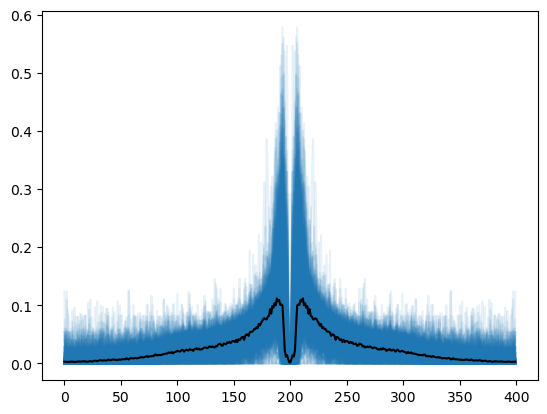

Label 1
Sham represented as 5.629666296691038
Tumor represented as 4.23749662758679
Median FR: 2.25 Hz
671


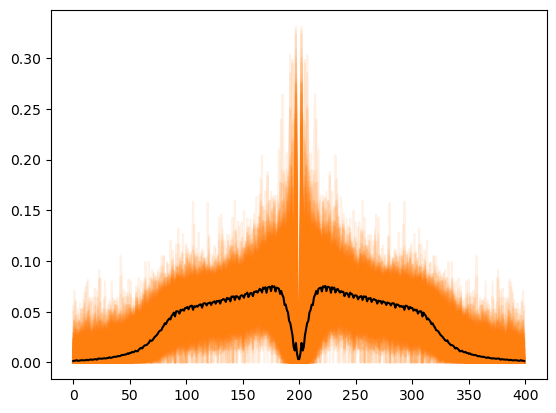

Label 2
Sham represented as 2.7479652578194163
Tumor represented as 5.412467204456079
Median FR: 1.57 Hz
427


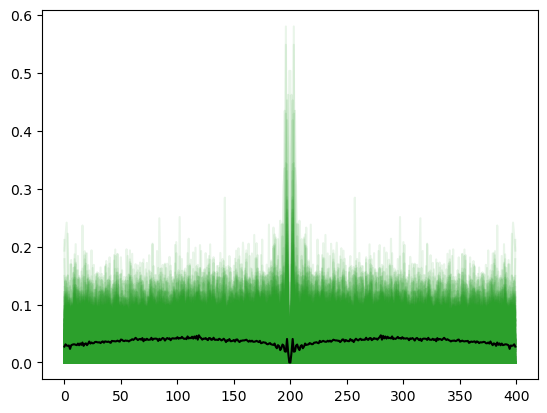

In [16]:
for label in np.unique(labels):
    if label == -1:
        continue
    mask = labels == label
    print(f"Label {label}")
    grp = group[mask]
    normalization = norm_factor[mask]
    unique_grps = np.unique(grp)
    grp0_mask = grp == unique_grps[0]
    print(f"{unique_grps[0]} represented as {np.sum(normalization[grp0_mask])}")

    if  len(unique_grps) > 1:
        grp1_mask = grp == unique_grps[1]
        print(f"{unique_grps[1]} represented as {np.sum(normalization[grp1_mask])}")
    else:
        print(f"Only one group present: {unique_grps[0]}")

    mean_acg = np.median(acgs[mask], axis=0)
    median_fr = np.median(frs[mask])
    print(f"Median FR: {median_fr:.2f} Hz")

    print(np.sum(mask))
    plt.figure()
    plt.plot(acgs[mask].T, alpha=0.1, c=f"C{label}")
    plt.plot(mean_acg, label=f"Label {label}", c="black", alpha=1)
    plt.show()


In [17]:
acgs_1 = acgs_original[labels == 0]
acgs_2 = acgs_original[labels == 1]
acgs_3 = acgs_original[labels == 2]


In [18]:
rec_names = np.array(rec_names)
labels = np.array(labels)
group  = np.array(group)

In [19]:

from scipy.stats import mannwhitneyu

recs = {}
counts_in_rec = {}

for rec_name in np.unique(rec_names):
    rec_mask = rec_names == rec_name
    labels_in_rec = labels[rec_mask]
    group_of_rec = group[rec_mask][0]
    recs[rec_name] = group_of_rec
    counts_in_rec[rec_name] = np.unique(labels_in_rec, return_counts=True)
    

In [20]:
all_records_data = []
for rec_name, (labels, counts) in counts_in_rec.items():
    record_dict = {label: count for label, count in zip(labels, counts)}
    all_records_data.append(record_dict)
df = pd.DataFrame(all_records_data, index=counts_in_rec.keys())
df = df.fillna(0).astype(int)
df = df.reindex(sorted(df.columns), axis=1)
df.columns = [f"label_{col}" for col in df.columns]
df[df.columns] = df.to_numpy() / df.to_numpy().sum(axis=1, keepdims=True)
df = pd.merge(df, df_overview[["folder","group"]], left_index=True, right_on="folder", how="left")
print(df)


     label_0   label_1   label_2  folder  group
0   0.105263  0.228070  0.666667  8561_3  Tumor
1   0.239130  0.391304  0.369565  8561_5  Tumor
2   0.212766  0.638298  0.148936  8562_5   Sham
3   0.241245  0.603113  0.155642  8562_7   Sham
4   0.000000  0.583333  0.416667  8602_1  Tumor
5   0.166667  0.444444  0.388889  8602_2  Tumor
6   0.400000  0.340000  0.260000  8602_5  Tumor
7   0.327869  0.377049  0.295082  8602_6  Tumor
8   0.100000  0.660000  0.240000  8603_1  Tumor
9   0.125000  0.500000  0.375000  8603_2  Tumor
10  0.032258  0.451613  0.516129  8604_1  Tumor
11  0.375000  0.000000  0.625000  8604_2  Tumor
12  0.084112  0.261682  0.654206  8604_5  Tumor
13  0.394737  0.000000  0.605263  8604_6  Tumor
14  0.340426  0.531915  0.127660  8605_1   Sham
15  0.060606  0.575758  0.363636  8605_2   Sham
16  0.198198  0.603604  0.198198  8605_5   Sham
17  0.070588  0.635294  0.294118  8605_6   Sham
18  0.153846  0.153846  0.692308  8606_1   Sham
19  0.168539  0.651685  0.179775  8606_2

In [59]:
df

,label_0,label_1,label_2,folder,group
0,0.105263,0.228070,0.666667,8561_3,Tumor
1,0.239130,0.391304,0.369565,8561_5,Tumor
2,0.212766,0.638298,0.148936,8562_5,Sham
3,0.241245,0.603113,0.155642,8562_7,Sham
4,0.000000,0.583333,0.416667,8602_1,Tumor
5,0.166667,0.444444,0.388889,8602_2,Tumor
6,0.400000,0.340000,0.260000,8602_5,Tumor
7,0.327869,0.377049,0.295082,8602_6,Tumor
8,0.100000,0.660000,0.240000,8603_1,Tumor
9,0.125000,0.500000,0.375000,8603_2,Tumor


In [60]:
import skbio
skbio.__version__

'0.7.0'

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      22
number of groups                  2
test statistic             1.062468
p-value                      0.3302
number of permutations         9999
Name: PERMANOVA results, dtype: object


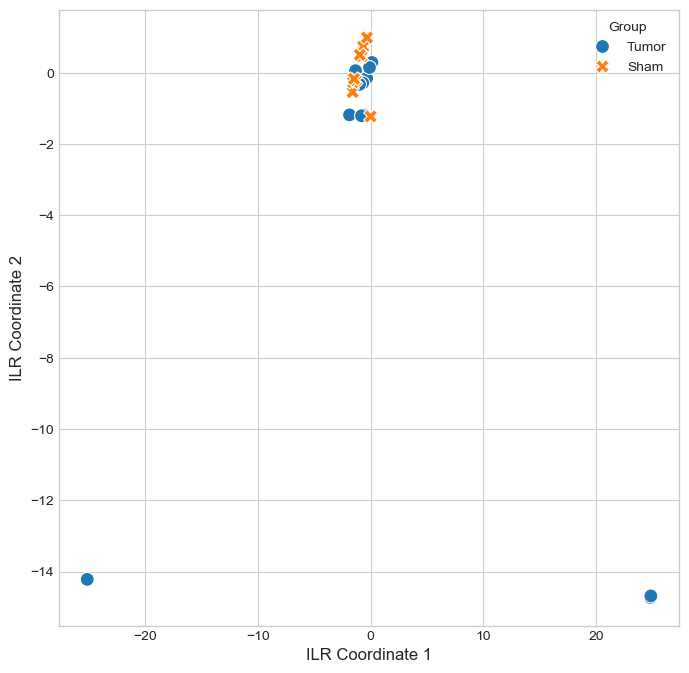

In [53]:
from sklearn.metrics.pairwise import euclidean_distances
from skbio.stats.distance import DistanceMatrix, permanova

composition_cols = ['label_0', 'label_1', 'label_2']
X = df[composition_cols]
def czm_replacement(matrix):
    if not isinstance(matrix, np.ndarray):
        matrix = np.array(matrix)
    if np.any(matrix < 0): raise ValueError("Matrix contains negative values.")
    if np.any(matrix.sum(axis=1) == 0): raise ValueError("Some rows sum to zero.")
    delta = np.finfo(float).eps
    matrix[matrix == 0] = delta
    return matrix / matrix.sum(axis=1, keepdims=True)
X_no_zeros = czm_replacement(X.values)
def ilr_transform_3d(matrix):
    if matrix.shape[1] != 3: raise ValueError("ILR transform is for 3-component data.")
    log_matrix = np.log(matrix)
    ilr_coord1 = (1/np.sqrt(2)) * (log_matrix[:, 0] - log_matrix[:, 1])
    ilr_coord2 = (1/np.sqrt(6)) * (log_matrix[:, 0] + log_matrix[:, 1] - 2 * log_matrix[:, 2])
    return np.vstack([ilr_coord1, ilr_coord2]).T
ilr_coords = ilr_transform_3d(X_no_zeros)
df_ilr = pd.DataFrame(ilr_coords, columns=['ilr_coord_1', 'ilr_coord_2'])


euclidean_dist_matrix = euclidean_distances(df_ilr)


euclidean_dist_matrix = (euclidean_dist_matrix + euclidean_dist_matrix.T) / 2 #fix floating point issues
np.fill_diagonal(euclidean_dist_matrix, 0)

dist_matrix = DistanceMatrix(euclidean_dist_matrix, ids=df.index)
permanova_results = permanova(dist_matrix, grouping=df['group'], permutations=9999)

print(permanova_results)
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=df_ilr.assign(group=df['group']),
    x='ilr_coord_1',
    y='ilr_coord_2',
    hue='group',
    style='group',
    s=100,
    ax=ax
)
ax.set_xlabel('ILR Coordinate 1', fontsize=12)
ax.set_ylabel('ILR Coordinate 2', fontsize=12)
ax.legend(title='Group', fontsize=10)
plt.show()

In [57]:
df_ilr = df_ilr.assign(group=df['group'])

In [58]:
df_ilr.to_excel("data/ilr_coordinates.xlsx")

In [67]:
for group in df['group'].unique():
    mask = df['group'] == group
    df_masked = df[mask].copy()
    df_masked[composition_cols].mean(axis=0)
    means = df_masked[composition_cols].mean(axis=0)
    stds = df_masked[composition_cols].std(axis=0)
    print(f"{group}:")
    for label in np.unique(labels):
        print(f"Cluster {label+1}: {means.iloc[label]:.2f} ± {stds.iloc[label]:.2f}")
    

Tumor:
Cluster 1: 0.20 ± 0.15
Cluster 2: 0.35 ± 0.21
Cluster 3: 0.45 ± 0.16
Sham:
Cluster 1: 0.16 ± 0.09
Cluster 2: 0.56 ± 0.15
Cluster 3: 0.27 ± 0.17


In [ ]:
np.save(file="data/transformed_acgs.npy", arr=transformed)
np.save(file="data/acg_labels.npy", arr=labels)
np.save(file="data/acg_components.npy", arr=components)
np.save(file="data/acg_frs.npy", arr=frs)
np.save(file="data/acg_groups.npy", arr=group)
np.save(file="data/acg_rec_names.npy", arr=rec_names)
np.save(file="data/acg_bin_centers.npy", arr=bin_centers)
np.save(file="data/acgs_cluster0.npy", arr=acgs_1)
np.save(file="data/acgs_cluster1.npy", arr=acgs_2)
np.save(file="data/acgs_cluster2.npy", arr=acgs_3)


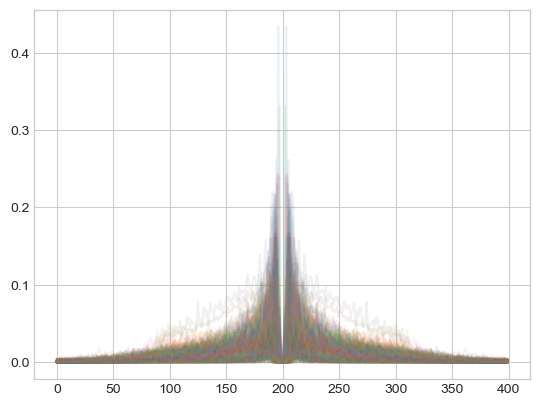

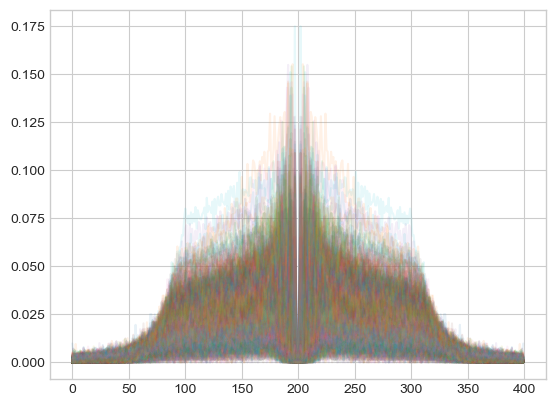

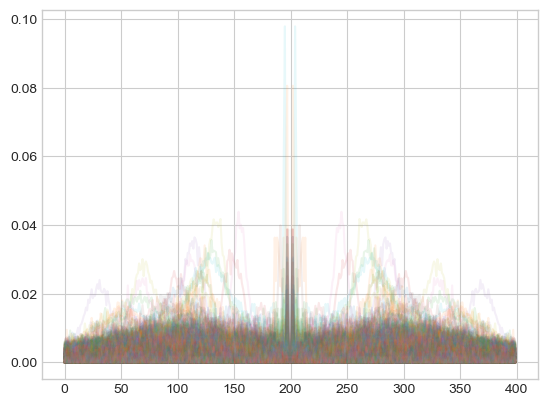

In [46]:
plt.figure()
plt.plot(acgs_1.T, alpha=0.1)
plt.show()

plt.figure()
plt.plot(acgs_2.T, alpha=0.1)
plt.show()

plt.figure()
plt.plot(acgs_3.T, alpha=0.1)
plt.show()

/tmp/ipykernel_10233/2176388978.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_boxplot.set_xticklabels(['Sham', 'Tumor'])


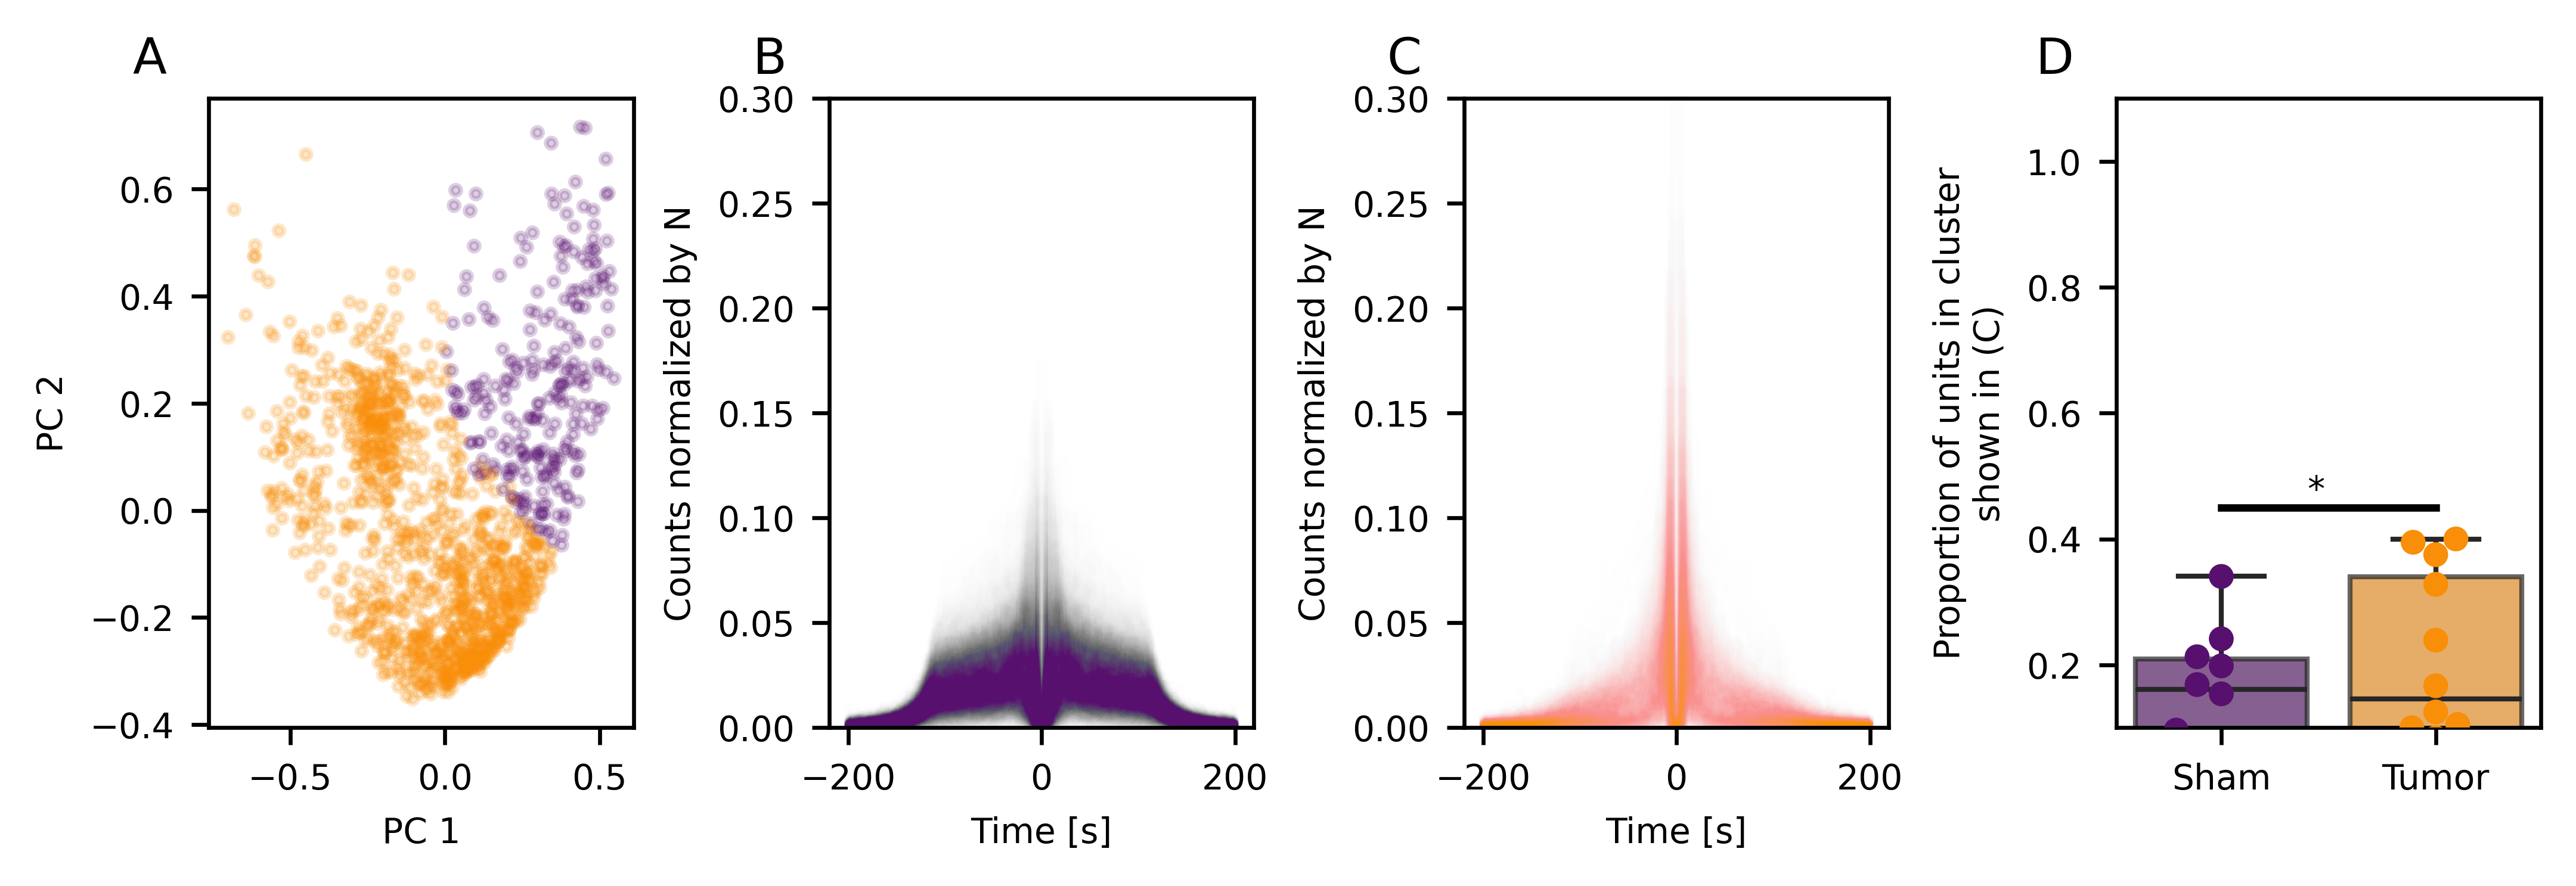

In [ ]:
import seaborn as sns
from data_analysis.plotting import get_c_map_colors

colors = get_c_map_colors(5)
plt.rcParams.update({'font.size': 7})
cm = 1/2.54
fig, axs = plt.subplots(nrows=1, 
                        ncols=4, 
                        figsize=(18*cm, 6*cm),
                        dpi=600, 
                        constrained_layout=True)
for label in np.unique(labels):
    mask = labels == label
    print(f"Label {label}")
    grp = group[mask]



In [ ]:
acgs = np.array(acgs)

Running ARI stability analysis for 500 iterations...


100%|██████████| 500/500 [00:33<00:00, 14.80it/s]



--- ARI Stability Analysis Results ---
Mean Adjusted Rand Index (ARI): 0.933 ± 0.077 (Mean ± SD)
Number of successful comparisons: 500/500


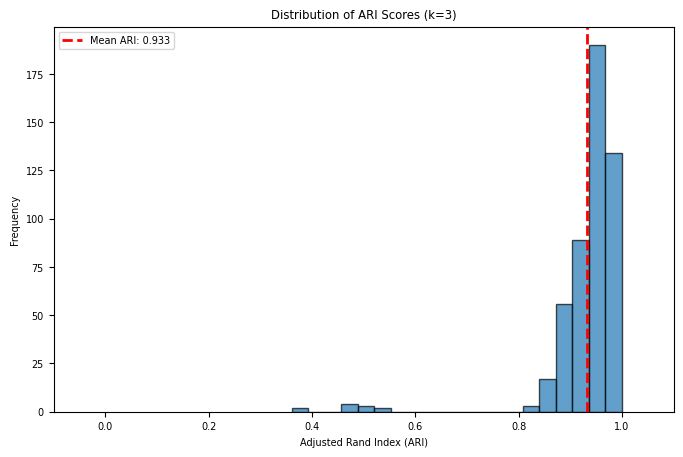

In [ ]:
from sklearn.metrics import adjusted_rand_score


def perform_clustering(data, n_clusters):
    """
    Performs PCA and K-Means clustering on the input data.
    """
    if data.shape[0] < n_clusters: 
        return None, None
        
    pca = PCA()
    transformed = pca.fit_transform(data)
    try:
        components = np.where(np.cumsum(pca.explained_variance_ratio_) > 0.9)[0][0] + 1
    except IndexError:
        components = transformed.shape[1]
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=np.random.randint(1000), max_iter=10000)
    labels = kmeans.fit_predict(transformed[:, :components])
    return labels

N_ITERATIONS = 500  
SUBSAMPLE_FRACTION = 0.8 
N_CLUSTERS = 3

ari_scores = []
n_total_samples = len(acgs)
n_subsample = int(n_total_samples * SUBSAMPLE_FRACTION)

print(f"Running ARI stability analysis for {N_ITERATIONS} iterations...")

for _ in tqdm(range(N_ITERATIONS)):
    indices_1 = np.random.choice(n_total_samples, n_subsample, replace=False)
    indices_2 = np.random.choice(n_total_samples, n_subsample, replace=False)

    labels_1 = perform_clustering(acgs[indices_1], N_CLUSTERS)
    labels_2 = perform_clustering(acgs[indices_2], N_CLUSTERS)

    if labels_1 is None or labels_2 is None:
        continue

    common_indices = np.intersect1d(indices_1, indices_2)
    if len(common_indices) < N_CLUSTERS: 
        continue

    common_mask_1 = np.isin(indices_1, common_indices)
    common_mask_2 = np.isin(indices_2, common_indices)
    
    sorted_common_indices = np.sort(common_indices)
    
    map_1 = {idx: i for i, idx in enumerate(indices_1)}
    map_2 = {idx: i for i, idx in enumerate(indices_2)}
    
    common_labels_1 = labels_1[[map_1[i] for i in sorted_common_indices]]
    common_labels_2 = labels_2[[map_2[i] for i in sorted_common_indices]]

    ari = adjusted_rand_score(common_labels_1, common_labels_2)
    ari_scores.append(ari)

ari_scores = np.array(ari_scores)

if len(ari_scores) > 0:
    mean_ari = np.mean(ari_scores)
    std_ari = np.std(ari_scores)
    print(f"Mean Adjusted Rand Index (ARI): {mean_ari:.3f} ± {std_ari:.3f} (Mean ± SD)")
    print(f"Number of successful comparisons: {len(ari_scores)}/{N_ITERATIONS}")

    plt.figure(figsize=(8, 5))
    plt.hist(ari_scores, bins=20, edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of ARI Scores (k={N_CLUSTERS})')
    plt.xlabel('Adjusted Rand Index (ARI)')
    plt.ylabel('Frequency')
    plt.xlim(-0.1, 1.1)
    plt.axvline(mean_ari, color='r', linestyle='--', linewidth=2, label=f'Mean ARI: {mean_ari:.3f}')
    plt.legend()
    plt.show()
else:
    print("Analysis failed. This might be due to too few common samples in the subsamples.")